In [155]:
! pip install qiskit ipywidgets
! pip install pylatexenc


In [156]:
! pip install qiskit-aer

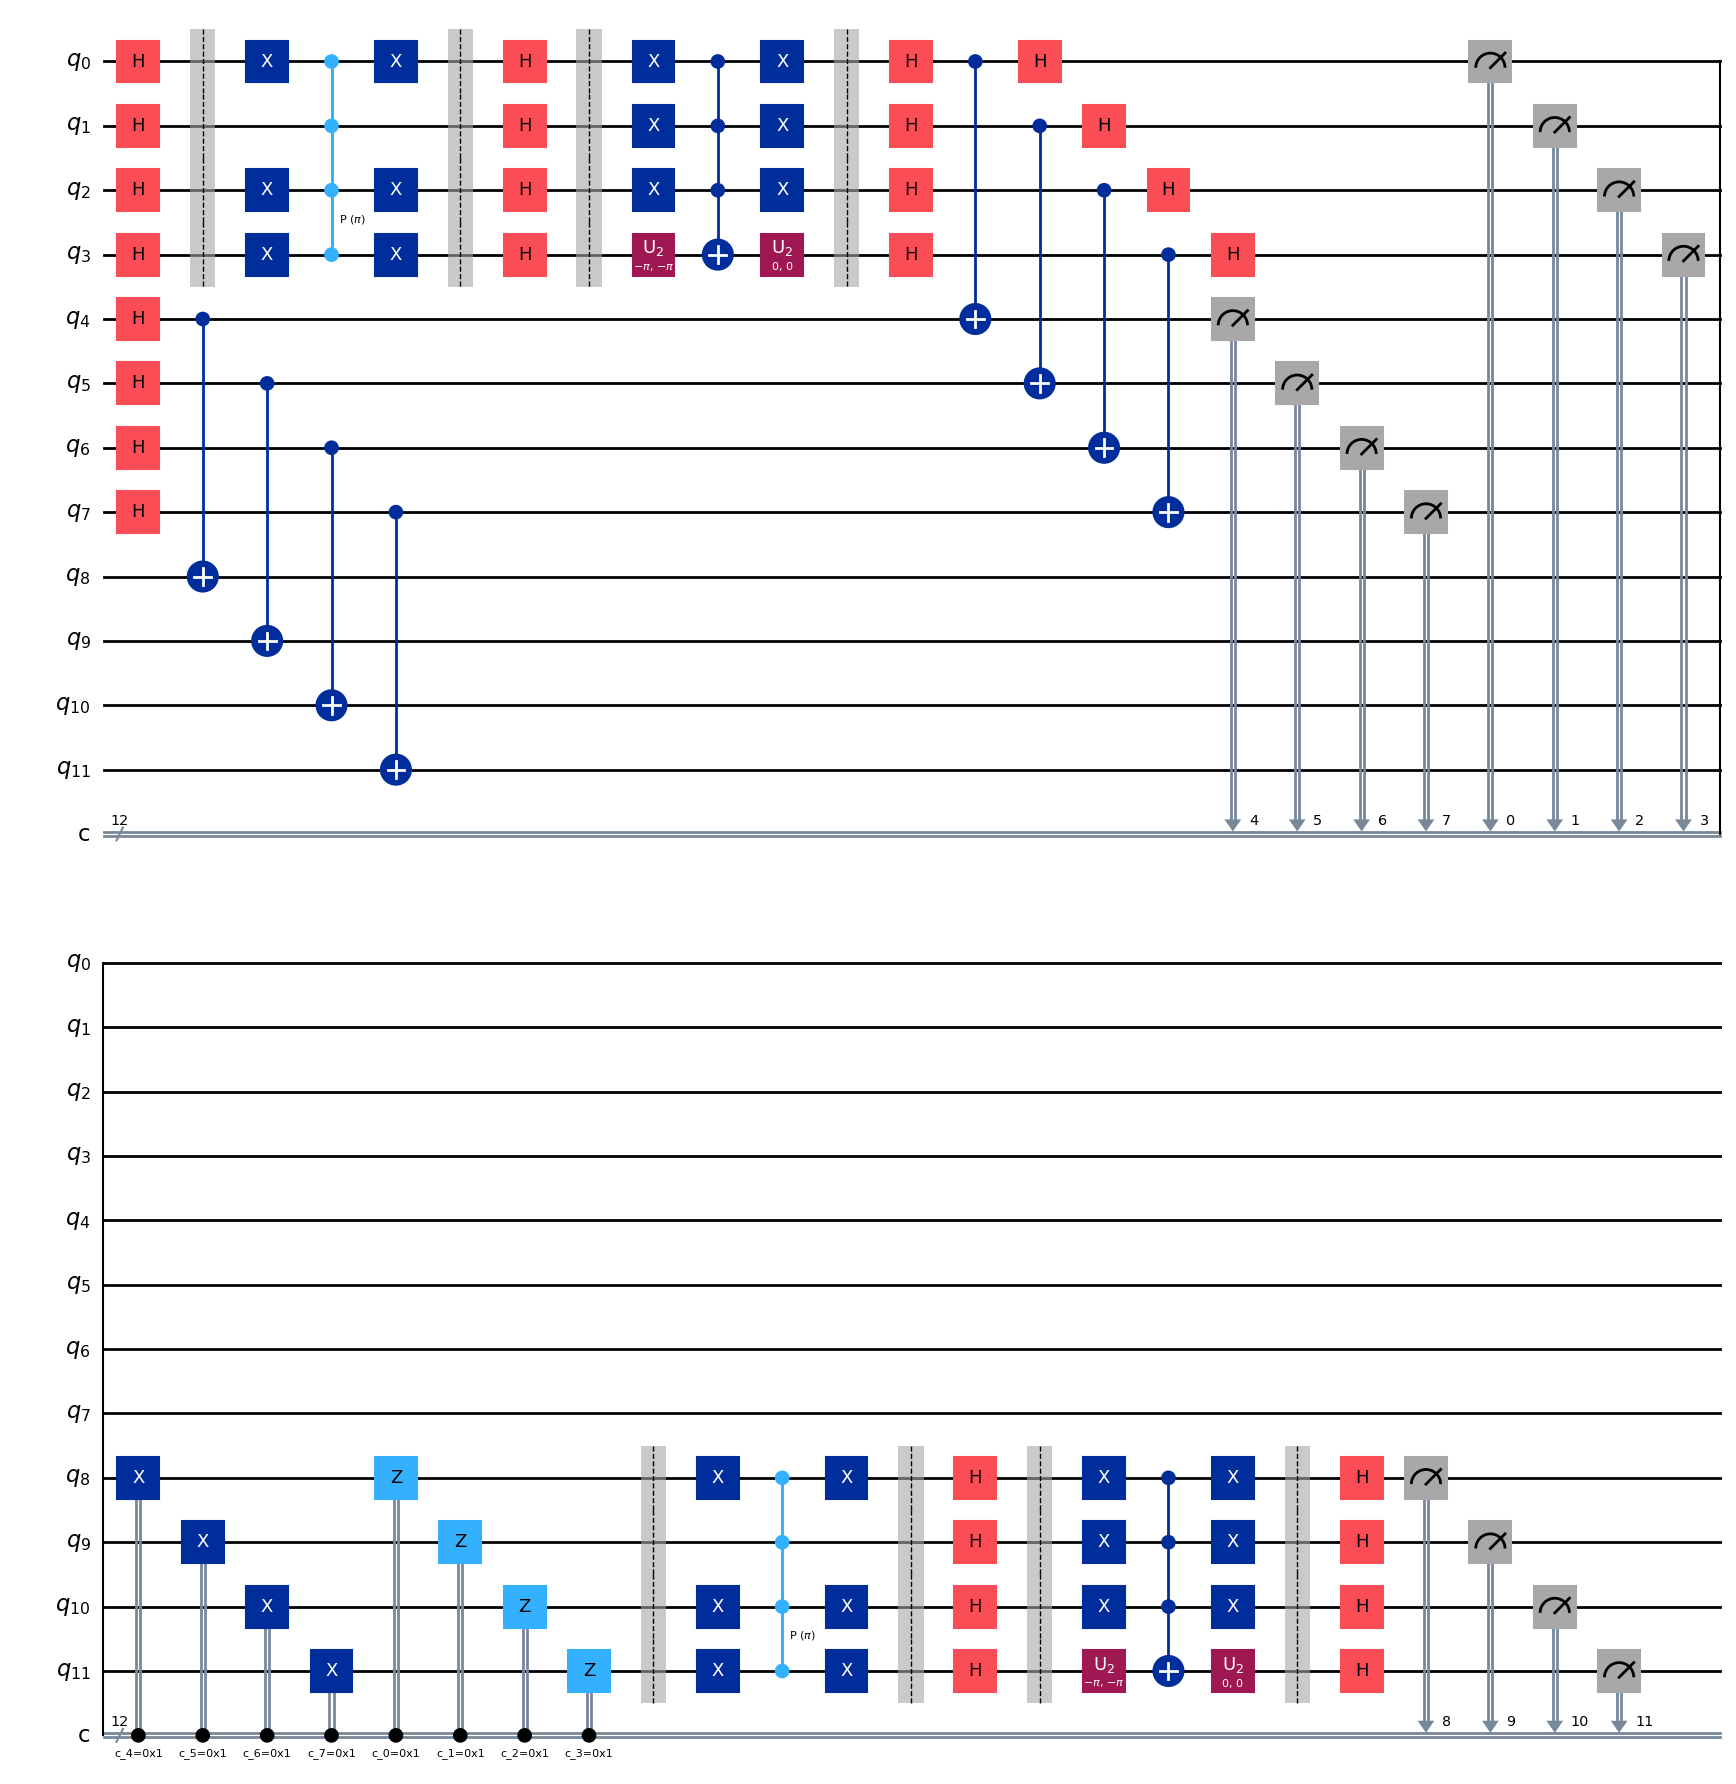

In [172]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_qsphere
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.circuit.library import GroverOperator
from math import pi
from qiskit import transpile
qc = QuantumCircuit(12,12)
qc.h(range(4))
qc.barrier(range(4))
mark_state = QuantumCircuit(4)
mark_state.x([0, 2, 3])
mark_state.mcp(pi, list(range(3)), 3)
mark_state.x([0, 2, 3])
grover_op = GroverOperator(mark_state, insert_barriers=True)
qc.append(grover_op, range(4))
Control = 0
Not = 4
qc.h(range(4,8))
qc.cx(range(4,8),range(8,12))
for i in range (4) :
  qc.cx(Control , Not)
  qc.h(Control)
  Control+=1
  Not+=1
qc.measure([4,5,6,7,0,1,2,3],[4,5,6,7,0,1,2,3])
#qc.barrier()
for i in range(4,8):
  qc.x(i+4).c_if(i,1)
for i in range(4):
  qc.z(i+8).c_if(i,1)
qc.barrier(range(8,12))
qc.append(grover_op, range(8,12))
simulator_aer = AerSimulator(seed_simulator=42)
qc.measure(range(8,12),range(8,12))
transpiled = transpile(qc , backend= simulator_aer)
transpiled.draw("mpl")

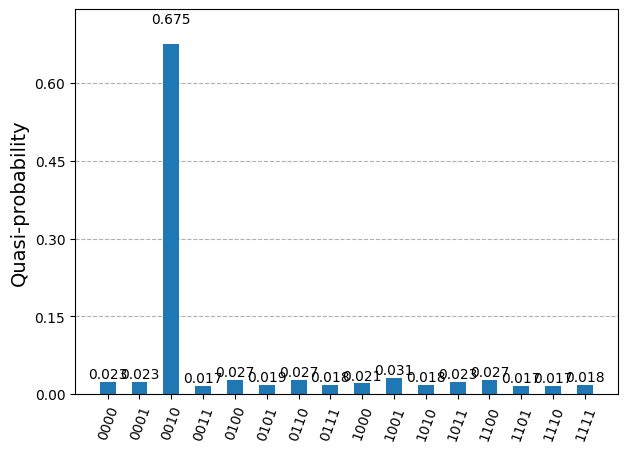

In [173]:
from qiskit_aer import noise
from qiskit.result import marginal_counts
from qiskit.visualization import plot_distribution
# Create depolarizing errors for different gate types
error1 = noise.depolarizing_error(0.001, 1)
error2 = noise.depolarizing_error(0.01, 2)
error3 = noise.depolarizing_error(0.1, 4)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error1, ['h', 'u2', 'x', 'z'])
noise_model.add_all_qubit_quantum_error(error2, ['cx'])
noise_model.add_all_qubit_quantum_error(error3, ['mcp', 'mcx'])
basic_gates = noise_model.basis_gates
noise = simulator_aer.run(transpiled,shots=1024,noise_model=noise_model, basis_gates=basic_gates).result()
counts = noise.get_counts()
marginal = marginal_counts(counts, indices=[8,9,10,11])
plot_distribution(marginal)